# Medium Magnet B0 Mapping

In [55]:
import mrc
import pypulseq as pp
import numpy as np
import matplotlib.pyplot as plt
import time

mrr = mrc.Console(frequency=8.05e6)

Connected to COM3


SerialException: could not open port 'COM3': PermissionError(13, 'Access is denied.', None, 5)

In [42]:
def create_1d_se(te, t90, t180, ro_time = None, pw_time = None):
    system = pp.Opts(max_grad=32, grad_unit='mT/m', max_slew=130, rf_raster_time=1/120e6, block_duration_raster=1/120e6, grad_raster_time=1/120e6, slew_unit='mT/m/ms')
    seq = pp.Sequence(system=system)

    dead_time = 10e-6

    grad_strength = 10
    grad_rise_time = 10e-6

    system = pp.Opts(max_grad=32, grad_unit='mT/m', max_slew=130, rf_raster_time=1/120e6, block_duration_raster=1/120e6, grad_raster_time=1/120e6, slew_unit='mT/m/ms')
    seq = pp.Sequence(system=system)

    if(ro_time is None):
        ro_time = 2e-3
    if(pw_time is None):
        pw_time = ro_time/2

    g_readout_x = pp.make_trapezoid(channel="y", flat_area=grad_strength, flat_time=ro_time, system=system)
    g_prewind_x = pp.make_trapezoid(channel="y", flat_area=grad_strength/2, flat_time=pw_time, system=system)

    rf90 = pp.make_block_pulse(flip_angle=np.pi/2, duration=t90, system=system)
    rf180 = pp.make_block_pulse(flip_angle=np.pi, duration=t180, phase_offset = np.pi/2, system=system)

    seq.add_block(rf90)
    seq.add_block(pp.make_delay(dead_time))
    seq.add_block(g_prewind_x)
    seq.add_block(pp.make_delay(te/2-t180/2 - pp.calc_duration(g_prewind_x) - dead_time))
    seq.add_block(rf180)
    seq.add_block(pp.make_delay((te-t180-pp.calc_duration(g_readout_x))/2))
    seq.add_block(g_readout_x)
    seq.add_block(pp.make_delay((te-t180-pp.calc_duration(g_readout_x))/2))

    return seq

In [271]:
def fieldmap(et = (5e-3,8e-3), t90=100e-6, t180=150e-6, points=30, ro_time = None, pw_time = None, plot=True):
    if(ro_time is None):
        ro_time = 2e-3
    if(pw_time is None):
        pw_time = ro_time/2
        
    seq1 = create_1d_se(et[0], t90, t180, ro_time=ro_time, pw_time=pw_time)
    seq2 = create_1d_se(et[1], t90, t180, ro_time=ro_time, pw_time=pw_time)
    mrr.run(seq1)
    dat1 = mrr.rx_data
    time.sleep(1)
    mrr.run(seq2)
    dat2 = mrr.rx_data

    bias = 15
    fs = 100e3
    center1 = int(fs*(et[0]+t90)+bias)
    center2 = int(fs*(et[1]+t90)+bias)
    halfwindow = int(fs*ro_time/2)
    
    e1 = dat1[center1-halfwindow:center1+halfwindow]
    e2 = dat2[center2-halfwindow:center2+halfwindow]

    fs = np.fft.fftshift(np.fft.fftfreq(len(e1), d=1/100e3))
    fte1 = np.fft.fftshift(np.fft.fft(np.fft.fftshift(e1)))
    fte2 = np.fft.fftshift(np.fft.fft(np.fft.fftshift(e2)))
    
    obj_center_idx = len(fte1)//2

    angles1 = np.unwrap(np.angle(fte1)[obj_center_idx-points//2:obj_center_idx+points//2])
    angles2 = np.unwrap(np.angle(fte2)[obj_center_idx-points//2:obj_center_idx+points//2])

    fieldmap = angles1 - angles2

    if(plot):
        tf, ax = plt.subplots(3,2)
        ax[0,0].plot(np.real(e1))
        ax[0,0].plot(np.imag(e1))
        ax[0,1].plot(np.real(e2))
        ax[0,1].plot(np.imag(e2))
        ax[1,0].plot(fs, np.real(fte1))
        ax[1,0].plot(fs, np.imag(fte1))
        ax[1,1].plot(fs, np.real(fte2))
        ax[1,1].plot(fs, np.imag(fte2))
        ax[2,0].plot(angles1)
        ax[2,0].plot(angles2)
        ax[2,1].plot(fieldmap)
        plt.tight_layout()
        plt.show()
    
    return fieldmap, dat1, dat2

In [269]:
te = 8e-3
t90 = 100e-6
t180 = 150e-6

seq = create_1d_se(te, t90, t180)
mrc.compile_sequence(seq, 'fieldmap8.mrc')

Loading Sequence... Done.
Running Sequence
Received Bytes: 3648

Loading Sequence... Done.
Running Sequence
Received Bytes: 7232



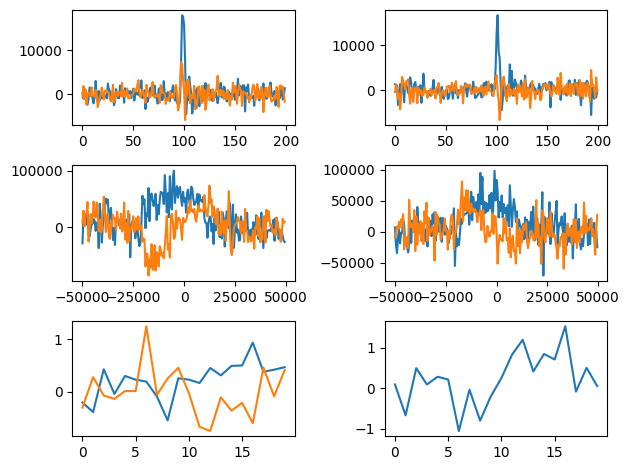

In [277]:
fmap, d1, d2 = fieldmap(et = (6e-3,12e-3), t90=100e-6, t180=100e-6, points=20, ro_time = 2e-3, pw_time = None, plot=True)

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



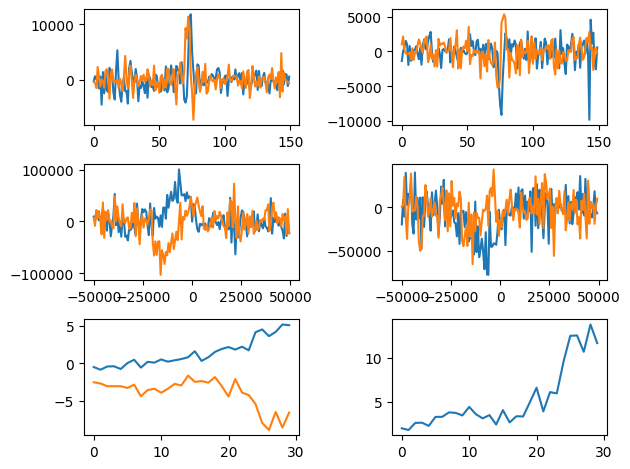

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



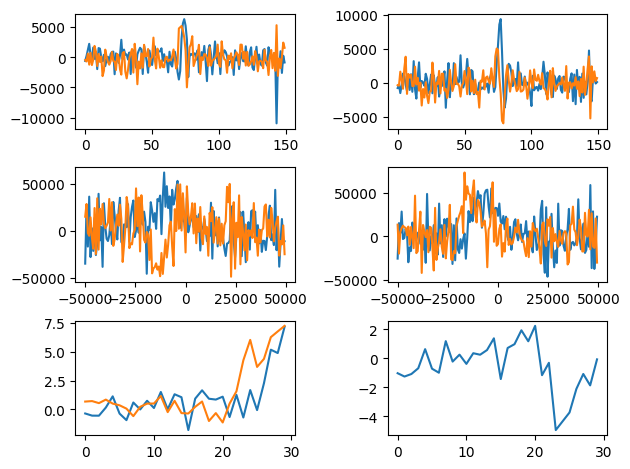

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



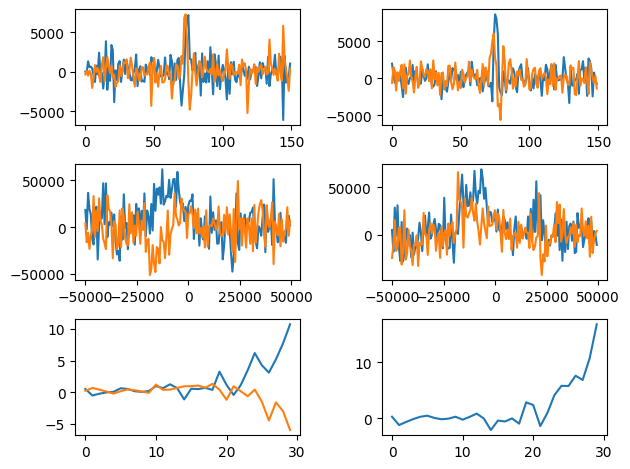

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



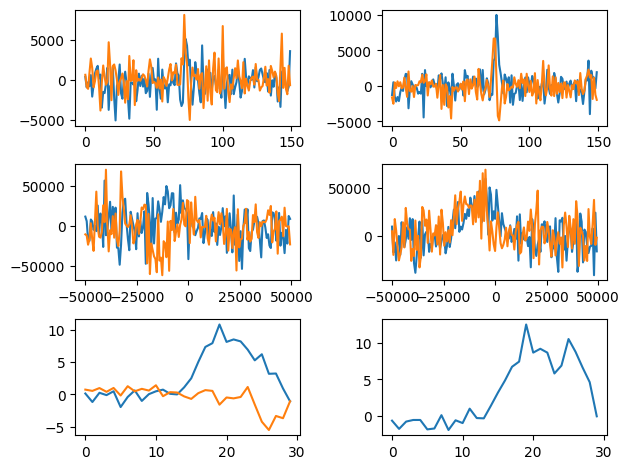

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



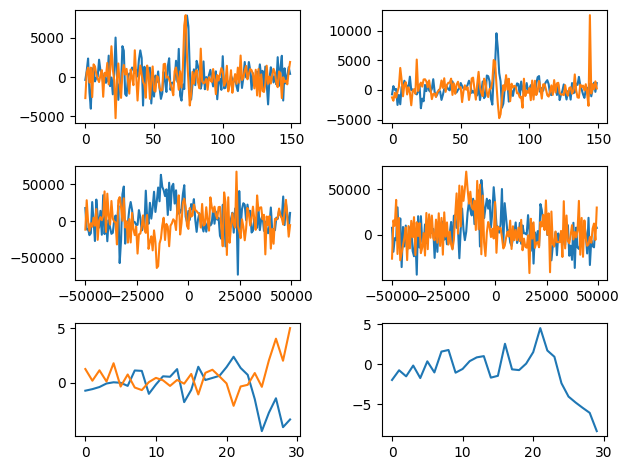

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



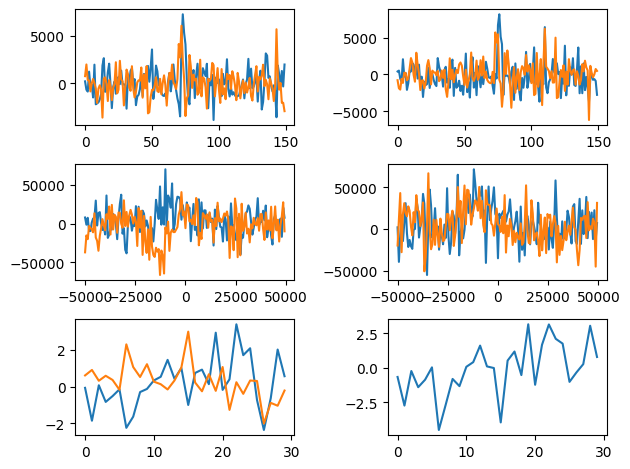

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



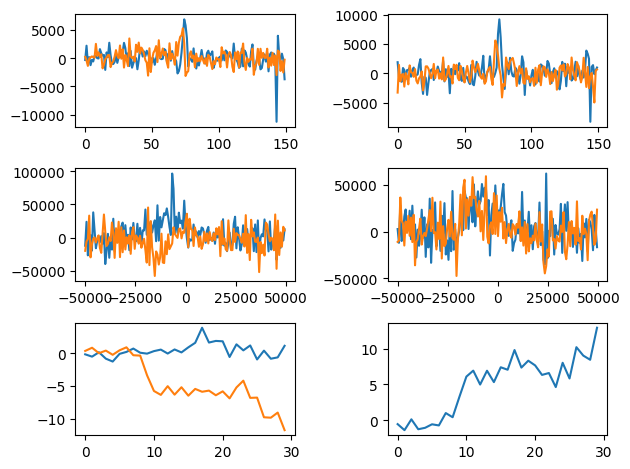

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



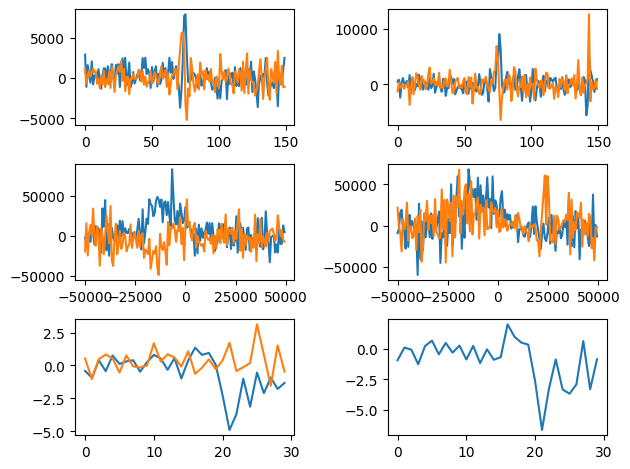

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



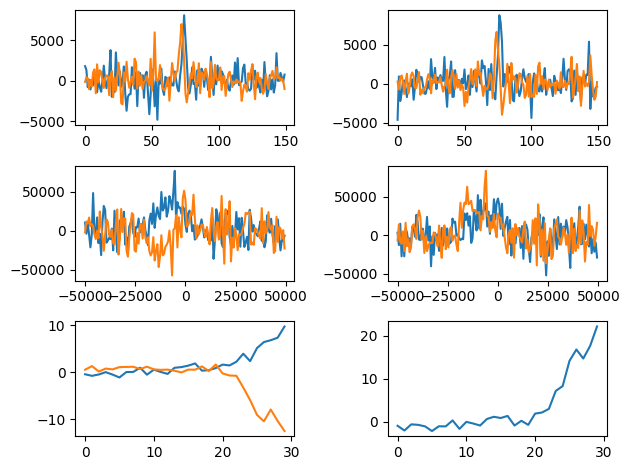

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



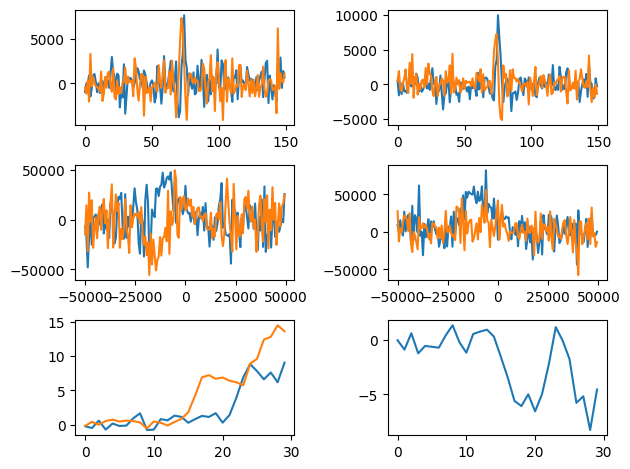

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



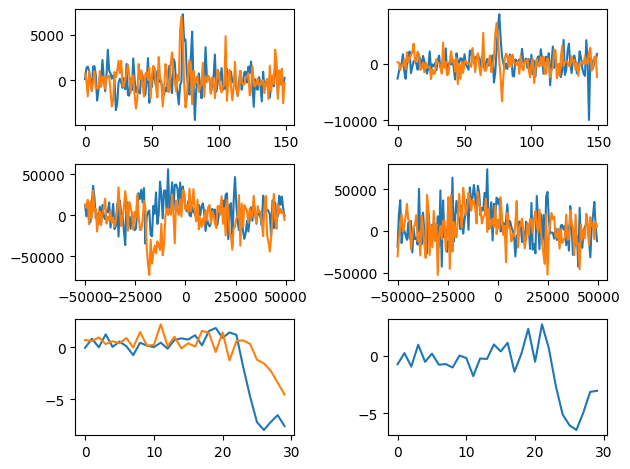

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



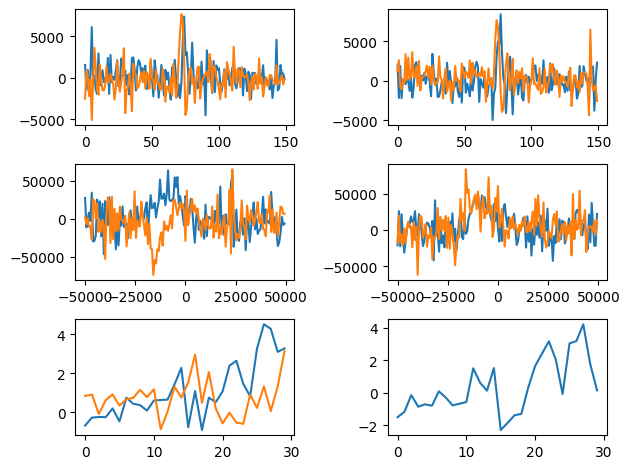

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



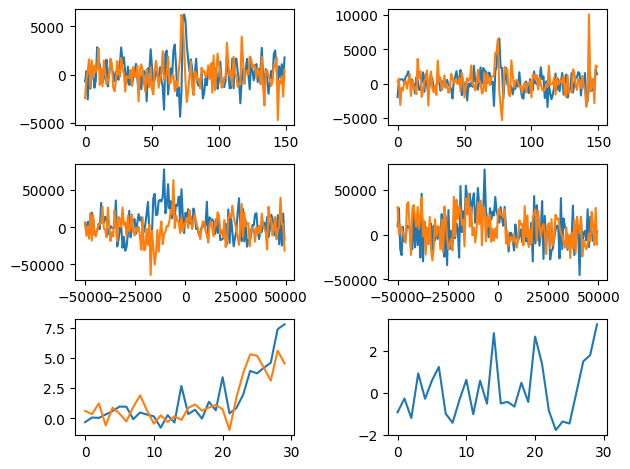

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



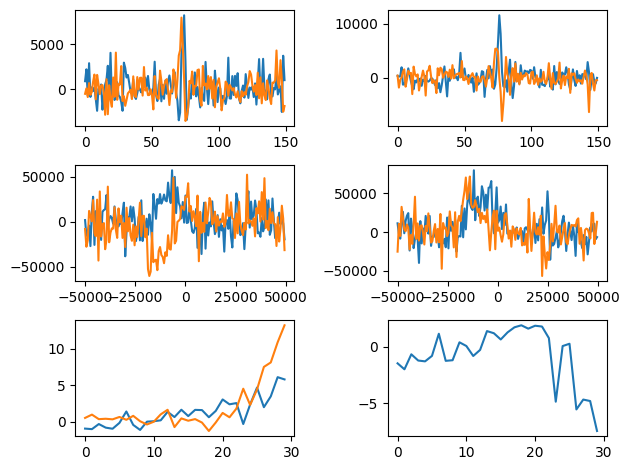

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



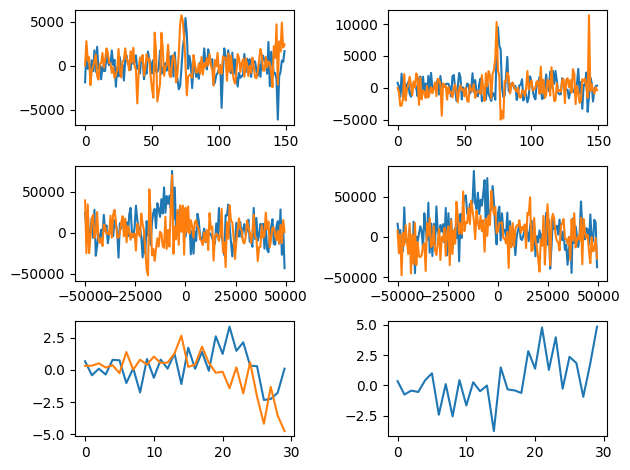

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



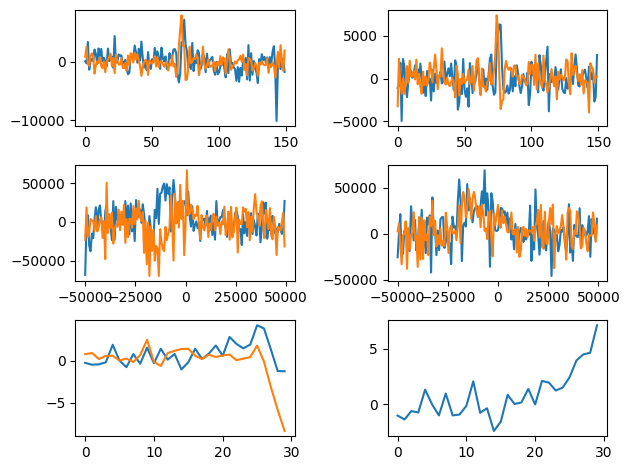

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



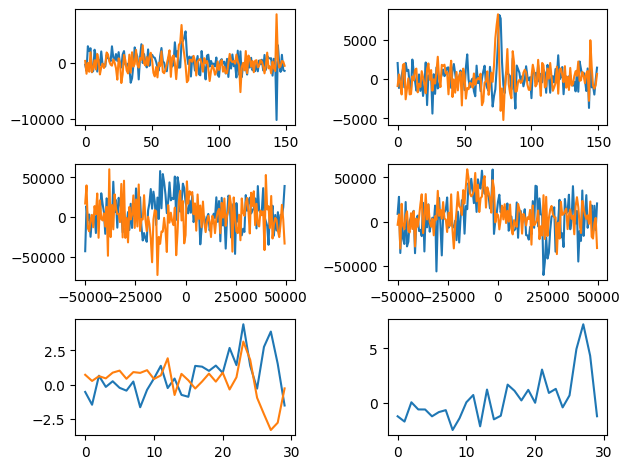

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



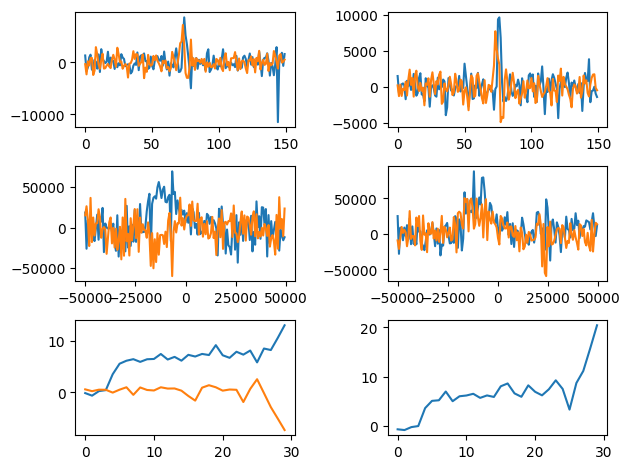

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



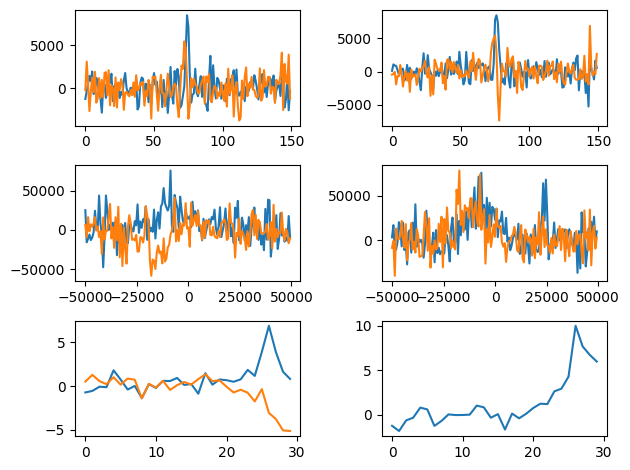

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



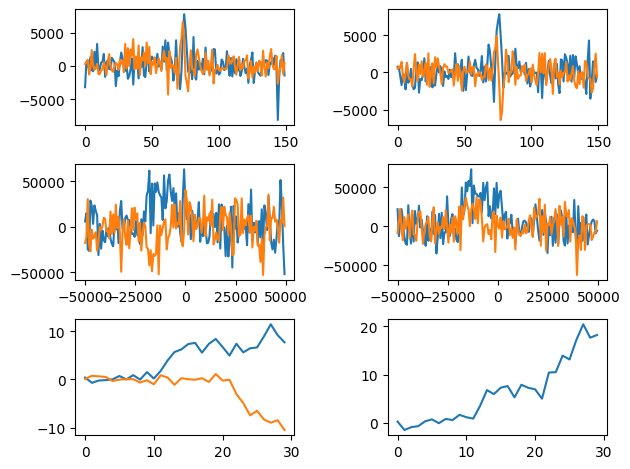

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



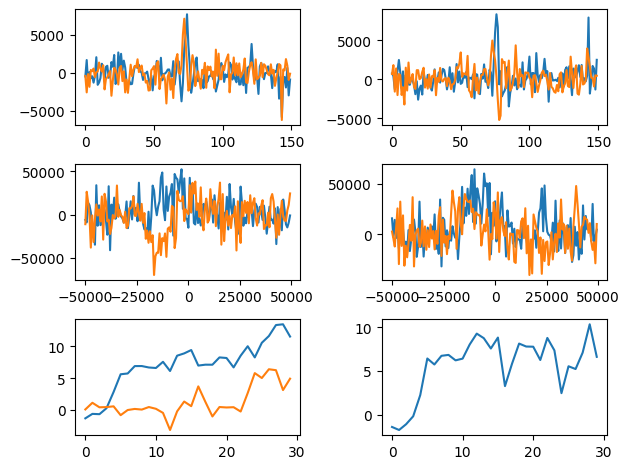

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



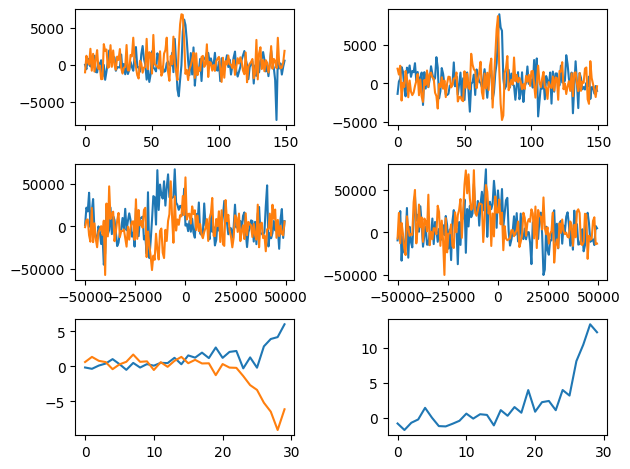

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



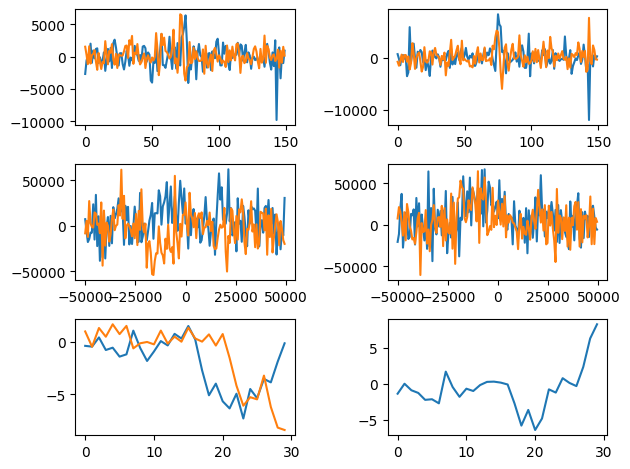

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



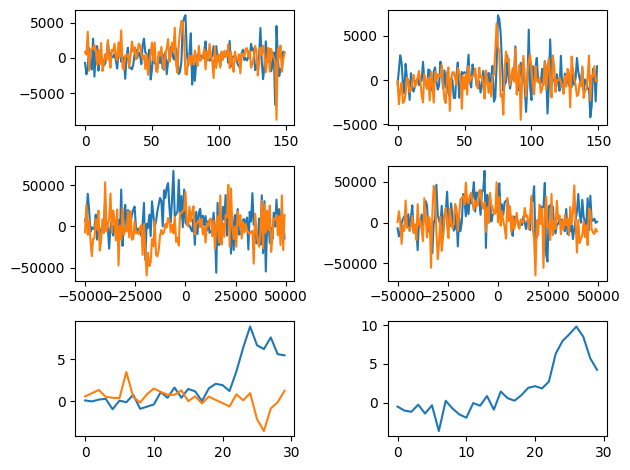

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



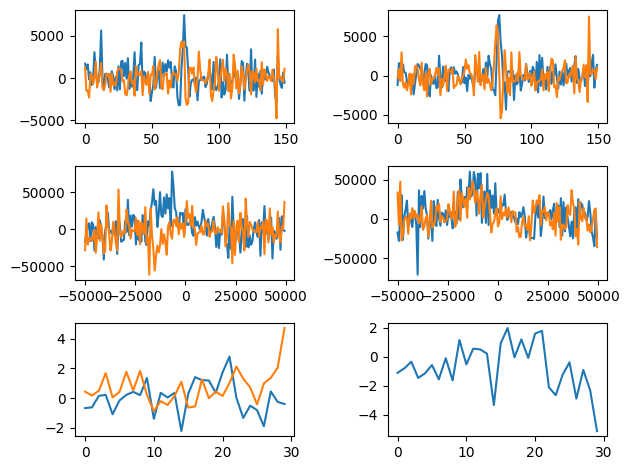

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



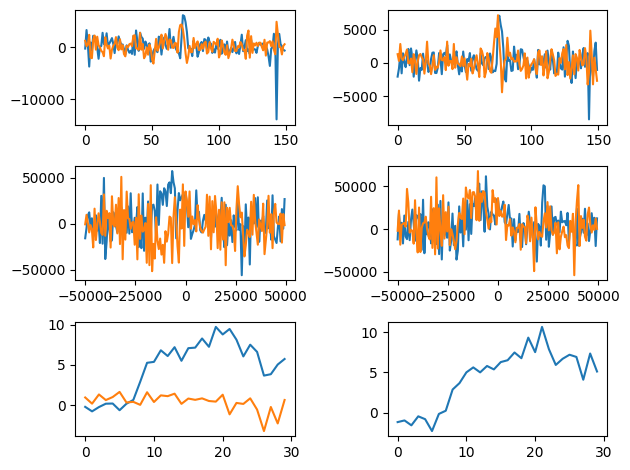

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



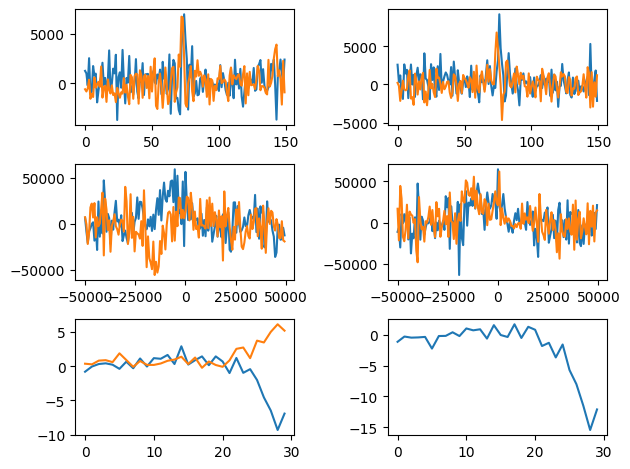

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



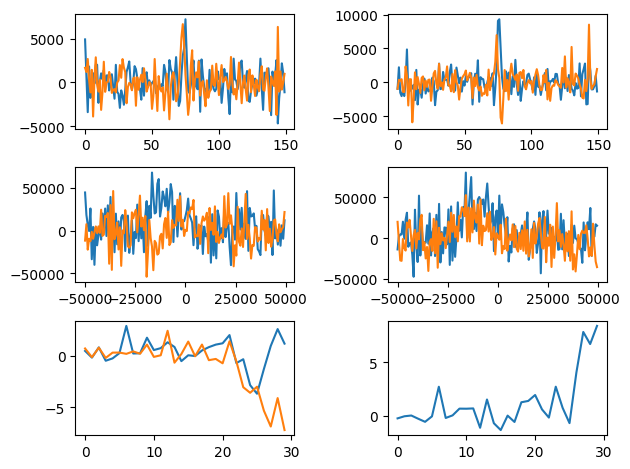

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



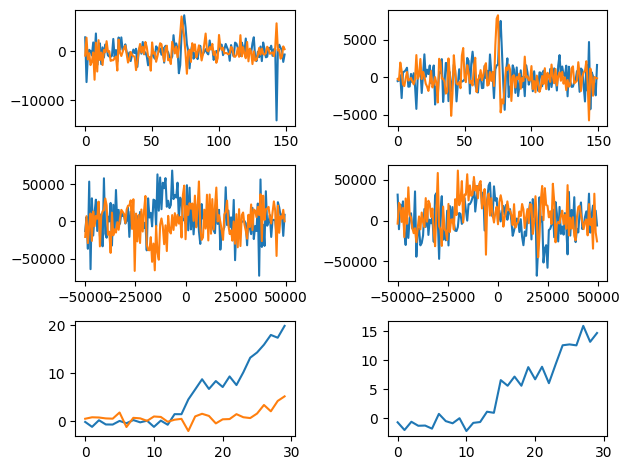

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



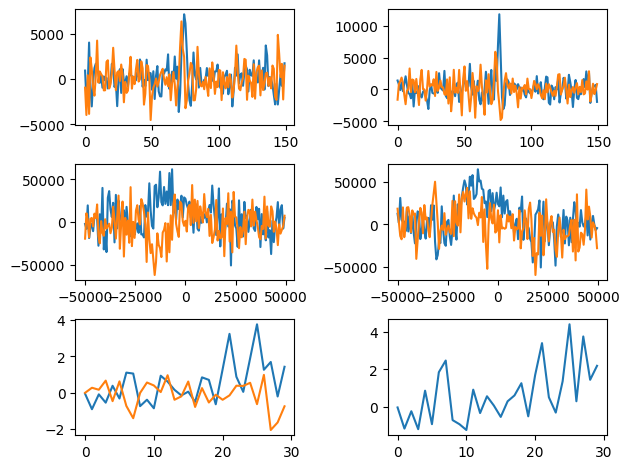

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



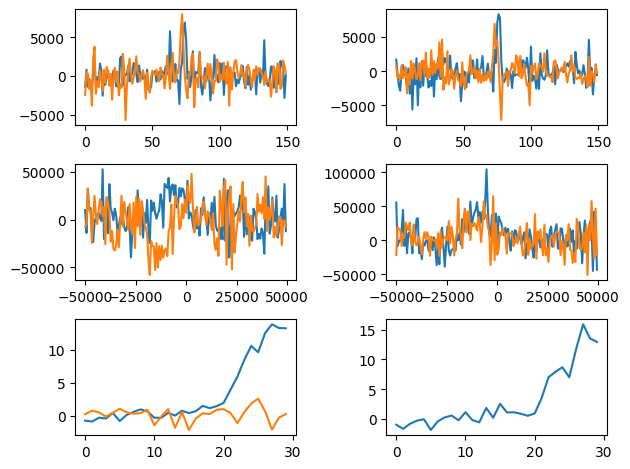

Loading Sequence... Done.
Running Sequence
Received Bytes: 3008

Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



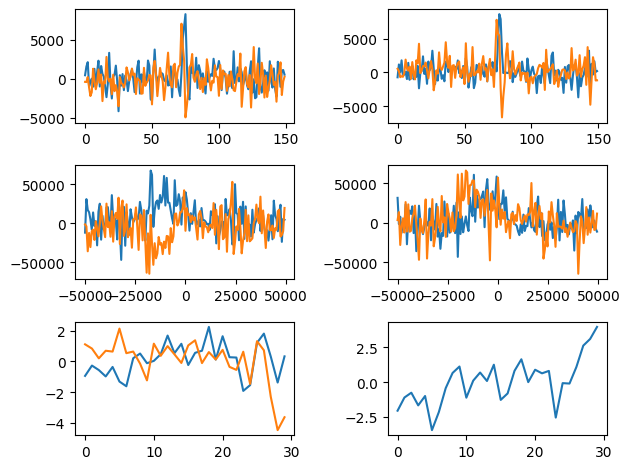

In [236]:
#run many times
import pickle
scans = 32
fmapt = np.zeros(30)
for i in range(scans):
    fmap, d1, d2 = fieldmap(et = (5e-3,15e-3), t90=150e-6, t180=150e-6, points=30, ro_time = 1.5e-3, pw_time = None, plot=True)
    time.sleep(1)
    with open(f'scan_distorted{i}.pickle', 'wb+') as f:
        pickle.dump((fmap, d1, d2), f)
    fmapt = fmapt + fmap

C:\Users\hansg\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\hansg\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


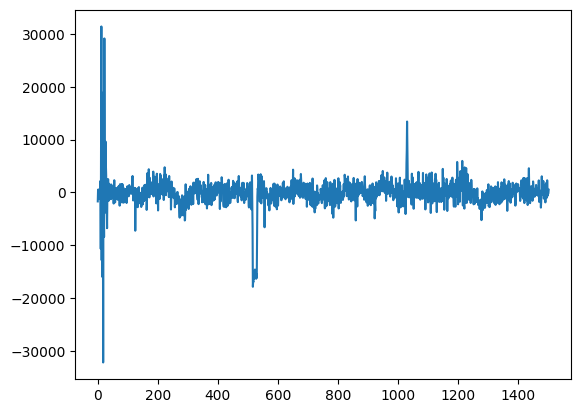

In [253]:
nn = plt.figure()
plt.plot(d2)
plt.show()

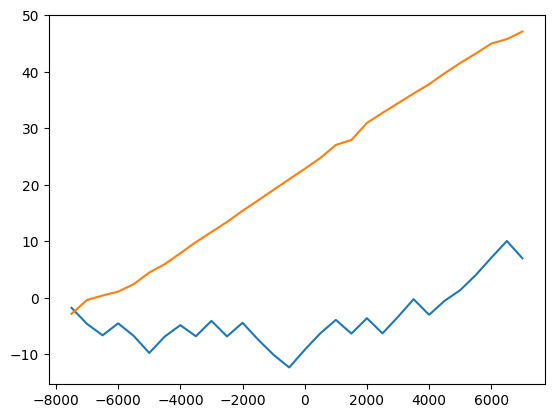

In [160]:
et = (5e-3,8e-3)
points = 30

tf = plt.figure()
bias = 23
fs = 100e3
center1 = int(fs*(et[0]+t90)+bias)
center2 = int(fs*(et[1]+t90)+bias)
halfwindow = int(fs*ro_time/2)

e1 = d1[center1-halfwindow:center1+halfwindow]
e2 = d2[center2-halfwindow:center2+halfwindow]

fs = np.fft.fftfreq(len(e1), d=1/100e3)
fte1 = np.fft.fftshift(np.fft.fft(np.fft.fftshift(e1)))
fte2 = np.fft.fftshift(np.fft.fft(np.fft.fftshift(e2)))

obj_center_idx = len(fte1)//2

plt.plot(np.fft.fftshift(fs)[obj_center_idx-points//2:obj_center_idx+points//2], 
         np.unwrap(np.angle(fte1)[obj_center_idx-points//2:obj_center_idx+points//2]))
plt.plot(np.fft.fftshift(fs)[obj_center_idx-points//2:obj_center_idx+points//2], 
         np.unwrap(np.angle(fte2)[obj_center_idx-points//2:obj_center_idx+points//2]))
# plt.plot(np.fft.fftshift(fs), np.imag(fte1))
# plt.xlim([-6000,6000])
plt.show()

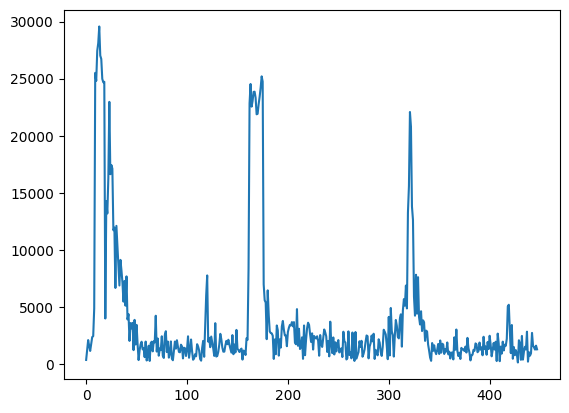

In [97]:
tn = plt.figure()
plt.plot(np.abs(mrr.rx_data))
plt.show()

Setting Coil Strength to 7 Counts/Hz
Setting Frequency to 8119000.0
Loading Sequence... Done.
Running Sequence
Received Bytes: 9024



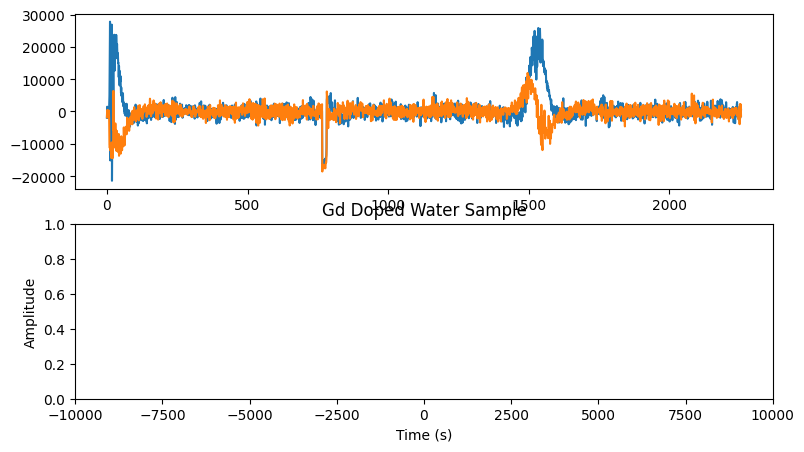

In [256]:
mrr.amp(7)
# mrr.attenuation(3)
# mrr.freq(8.06e6)
mrr.freq(8.119e6) # probe reading is 1866. Grounding magnet to probe is very good for noise
mrr.run(mrc.build_spinecho(15e-3, 150e-6, 150e-6))
cpmg_fig, ax = plt.subplots(2,1,figsize=(9,5))
ax[0].plot(np.real(mrr.rx_data))
ax[0].plot(np.imag(mrr.rx_data))

# ft = np.fft.fft(np.fft.fftshift(mrr.rx_data[700:1100]))
# fs = np.fft.fftfreq(len(ft), d=1/100e3)
# ax[1].plot(np.fft.fftshift(fs), np.real(np.fft.fftshift(ft)))
# ax[1].plot(np.fft.fftshift(fs), np.imag(np.fft.fftshift(ft)))
# ax[1].plot(np.fft.fftshift(fs), np.abs(np.fft.fftshift(ft)))
ax[1].set_xlim([-10000,10000])
plt.title("Gd Doped Water Sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()  

Loading Sequence... Done.
Running Sequence
Received Bytes: 4800



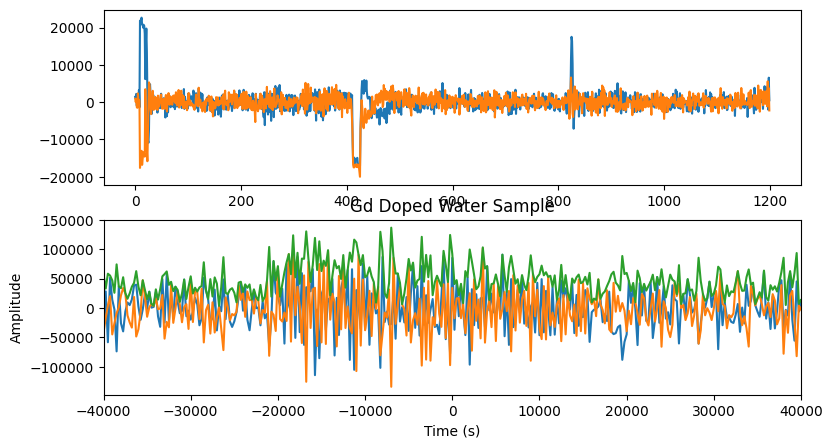

In [267]:
# mrr.amp(6)
# mrr.freq(8.111e6)
mrr.run('fieldmap8.mrc')

cpmg_fig, ax = plt.subplots(2,1,figsize=(9,5))
ax[0].plot(np.real(mrr.rx_data))
ax[0].plot(np.imag(mrr.rx_data))

# ft = np.fft.fft(np.fft.fftshift(mrr.rx_data[250:475]))
# ft = np.fft.fft(np.fft.fftshift(mrr.rx_data[450:600]))
ft = np.fft.fft(np.fft.fftshift(mrr.rx_data[800:9000]))
fs = np.fft.fftfreq(len(ft), d=1/100e3)
ax[1].plot(np.fft.fftshift(fs), np.real(np.fft.fftshift(ft)))
ax[1].plot(np.fft.fftshift(fs), np.imag(np.fft.fftshift(ft)))
ax[1].plot(np.fft.fftshift(fs), np.abs(np.fft.fftshift(ft)))
ax[1].set_xlim([-40000,40000])
plt.title("Gd Doped Water Sample")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.legend(["$T_2$ = %0.2f" % (mrc.get_t2(echo_amplitudes, 3e-3))]) # Put the calculated T2 in the legend
plt.show()  

In [57]:
np.save("fm8.npy", mrr.rx_data)

In [51]:
mrr.run(mrc.build_cpmg(6e-3, 100, 500e-6, 150e-6))

Loading Sequence... Done.
Running Sequence
Received Bytes: 241344



In [35]:
mrc.mrcdump('fieldmap.mrc')

Duration: 464
Statics:
Phase 0: 0
Phase 1: 16384
Phase 2: 0
Phase 3: 0

Amp 0: 0
Amp 1: 1250
Amp 2: 2500
Amp 3: 0

Instructions:
0:	0001000000000000	cmd 	1 0 00 00 00
1:	0101000000000100	lset	1 4
2:	0100111111111101	lset	0 4093
3:	1000000000000011	jmp 	0 3
4:	1001000000000010	jmp 	1 2
5:	0100110110111100	lset	0 3516
6:	1000000000000110	jmp 	0 6
7:	0000000000000000	cmd 	0 0 00 00 00
8:	0100010010101101	lset	0 1197
9:	1000000000001001	jmp 	0 9
10:	0000000100000000	cmd 	0 0 01 00 00
11:	0101000000011100	lset	1 28
12:	0100111111111101	lset	0 4093
13:	1000000000001101	jmp 	0 13
14:	1001000000001100	jmp 	1 12
15:	0100010010111100	lset	0 1212
16:	1000000000010000	jmp 	0 16
17:	0000000000000000	cmd 	0 0 00 00 00
18:	0101000000001010	lset	1 10
19:	0100111111111101	lset	0 4093
20:	1000000000010100	jmp 	0 20
21:	1001000000010011	jmp 	1 19
22:	0100011011001100	lset	0 1740
23:	1000000000010111	jmp 	0 23
24:	0010010000000000	cmd 	2 1 00 00 00
25:	0101000000000100	lset	1 4
26:	0100111111111101	lset	0

In [ ]:
def create_1d_se(te, t90, t180, ro_time = None, pw_time = None):
    system = pp.Opts(max_grad=32, grad_unit='mT/m', max_slew=130, rf_raster_time=1/120e6, block_duration_raster=1/120e6, grad_raster_time=1/120e6, slew_unit='mT/m/ms')
    seq = pp.Sequence(system=system)

    dead_time = 10e-6

    grad_strength = 10
    grad_rise_time = 10e-6

    system = pp.Opts(max_grad=32, grad_unit='mT/m', max_slew=130, rf_raster_time=1/120e6, block_duration_raster=1/120e6, grad_raster_time=1/120e6, slew_unit='mT/m/ms')
    seq = pp.Sequence(system=system)

    if(ro_time is None):
        ro_time = 2e-3
    if(pw_time is None):
        pw_time = ro_time/2

    g_px = pp.make_trapezoid(channel="x", flat_area=grad_strength, flat_time=ro_time, system=system)
    g_nx = pp.make_trapezoid(channel="x", flat_area=-grad_strength, flat_time=ro_time, system=system)
    g_py = pp.make_trapezoid(channel="y", flat_area=grad_strength, flat_time=ro_time, system=system)
    g_ny = pp.make_trapezoid(channel="y", flat_area=-grad_strength, flat_time=ro_time, system=system)
    g_pz = pp.make_trapezoid(channel="z", flat_area=grad_strength, flat_time=ro_time, system=system)
    g_nz = pp.make_trapezoid(channel="z", flat_area=-grad_strength, flat_time=ro_time, system=system)
    g_prewind_x = pp.make_trapezoid(channel="y", flat_area=grad_strength/2, flat_time=pw_time, system=system)

    rf90 = pp.make_block_pulse(flip_angle=np.pi/2, duration=t90, system=system)
    rf180 = pp.make_block_pulse(flip_angle=np.pi, duration=t180, phase_offset = np.pi/2, system=system)

    seq.add_block(rf90)
    seq.add_block(pp.make_delay(dead_time))
    seq.add_block(g_px, g_py, g_pz)
    seq.add_block(pp.make_delay(te/2-t180/2 - pp.calc_duration(g_prewind_x) - dead_time))
    seq.add_block(rf180)
    seq.add_block(pp.make_delay((te-t180-pp.calc_duration(g_px))/2))
    seq.add_block(g_nx, g_ny, g_nz)
    seq.add_block(pp.make_delay((te-t180-pp.calc_duration(g_px))/2))

    return seq